# Decision Tree(의사결정 나무)

## Lib 및 데이터 로딩

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [2]:
data_path = 'datas_ml/Social_Network_Ads.csv'
df = pd.read_csv(data_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
y = df['Purchased']
X = df.loc[:, ['Gender', 'Age', 'EstimatedSalary']]

In [5]:
# 방법 1: map 사용 (가장 직관적)
X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
# 방법 2
# X['Gender'] = X['Gender'].replace({'Male': 0, 'Female': 1})

In [6]:
X.head()

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


In [7]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

## train, test 데이터 분할

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

In [9]:
X_train.shape, y_train.shape

((300, 3), (300,))

In [10]:
X_test.shape, y_test.shape

((100, 3), (100,))

## 모델 학습

In [30]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4
)

In [31]:
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

In [33]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.84

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        68
           1       0.81      0.66      0.72        32

    accuracy                           0.84       100
   macro avg       0.83      0.79      0.81       100
weighted avg       0.84      0.84      0.84       100



#2
max_depth=6,
min_samples_split=4

정확도: 0.84

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        68
           1       0.81      0.66      0.72        32

    accuracy                           0.84       100
   macro avg       0.83      0.79      0.81       100
weighted avg       0.84      0.84      0.84       100


#1 아무 제약 없을때
정확도: 0.81

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        68
           1       0.72      0.66      0.69        32

    accuracy                           0.81       100
   macro avg       0.78      0.77      0.78       100
weighted avg       0.81      0.81      0.81       100

## 학습모델 결정트리 시각화

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os

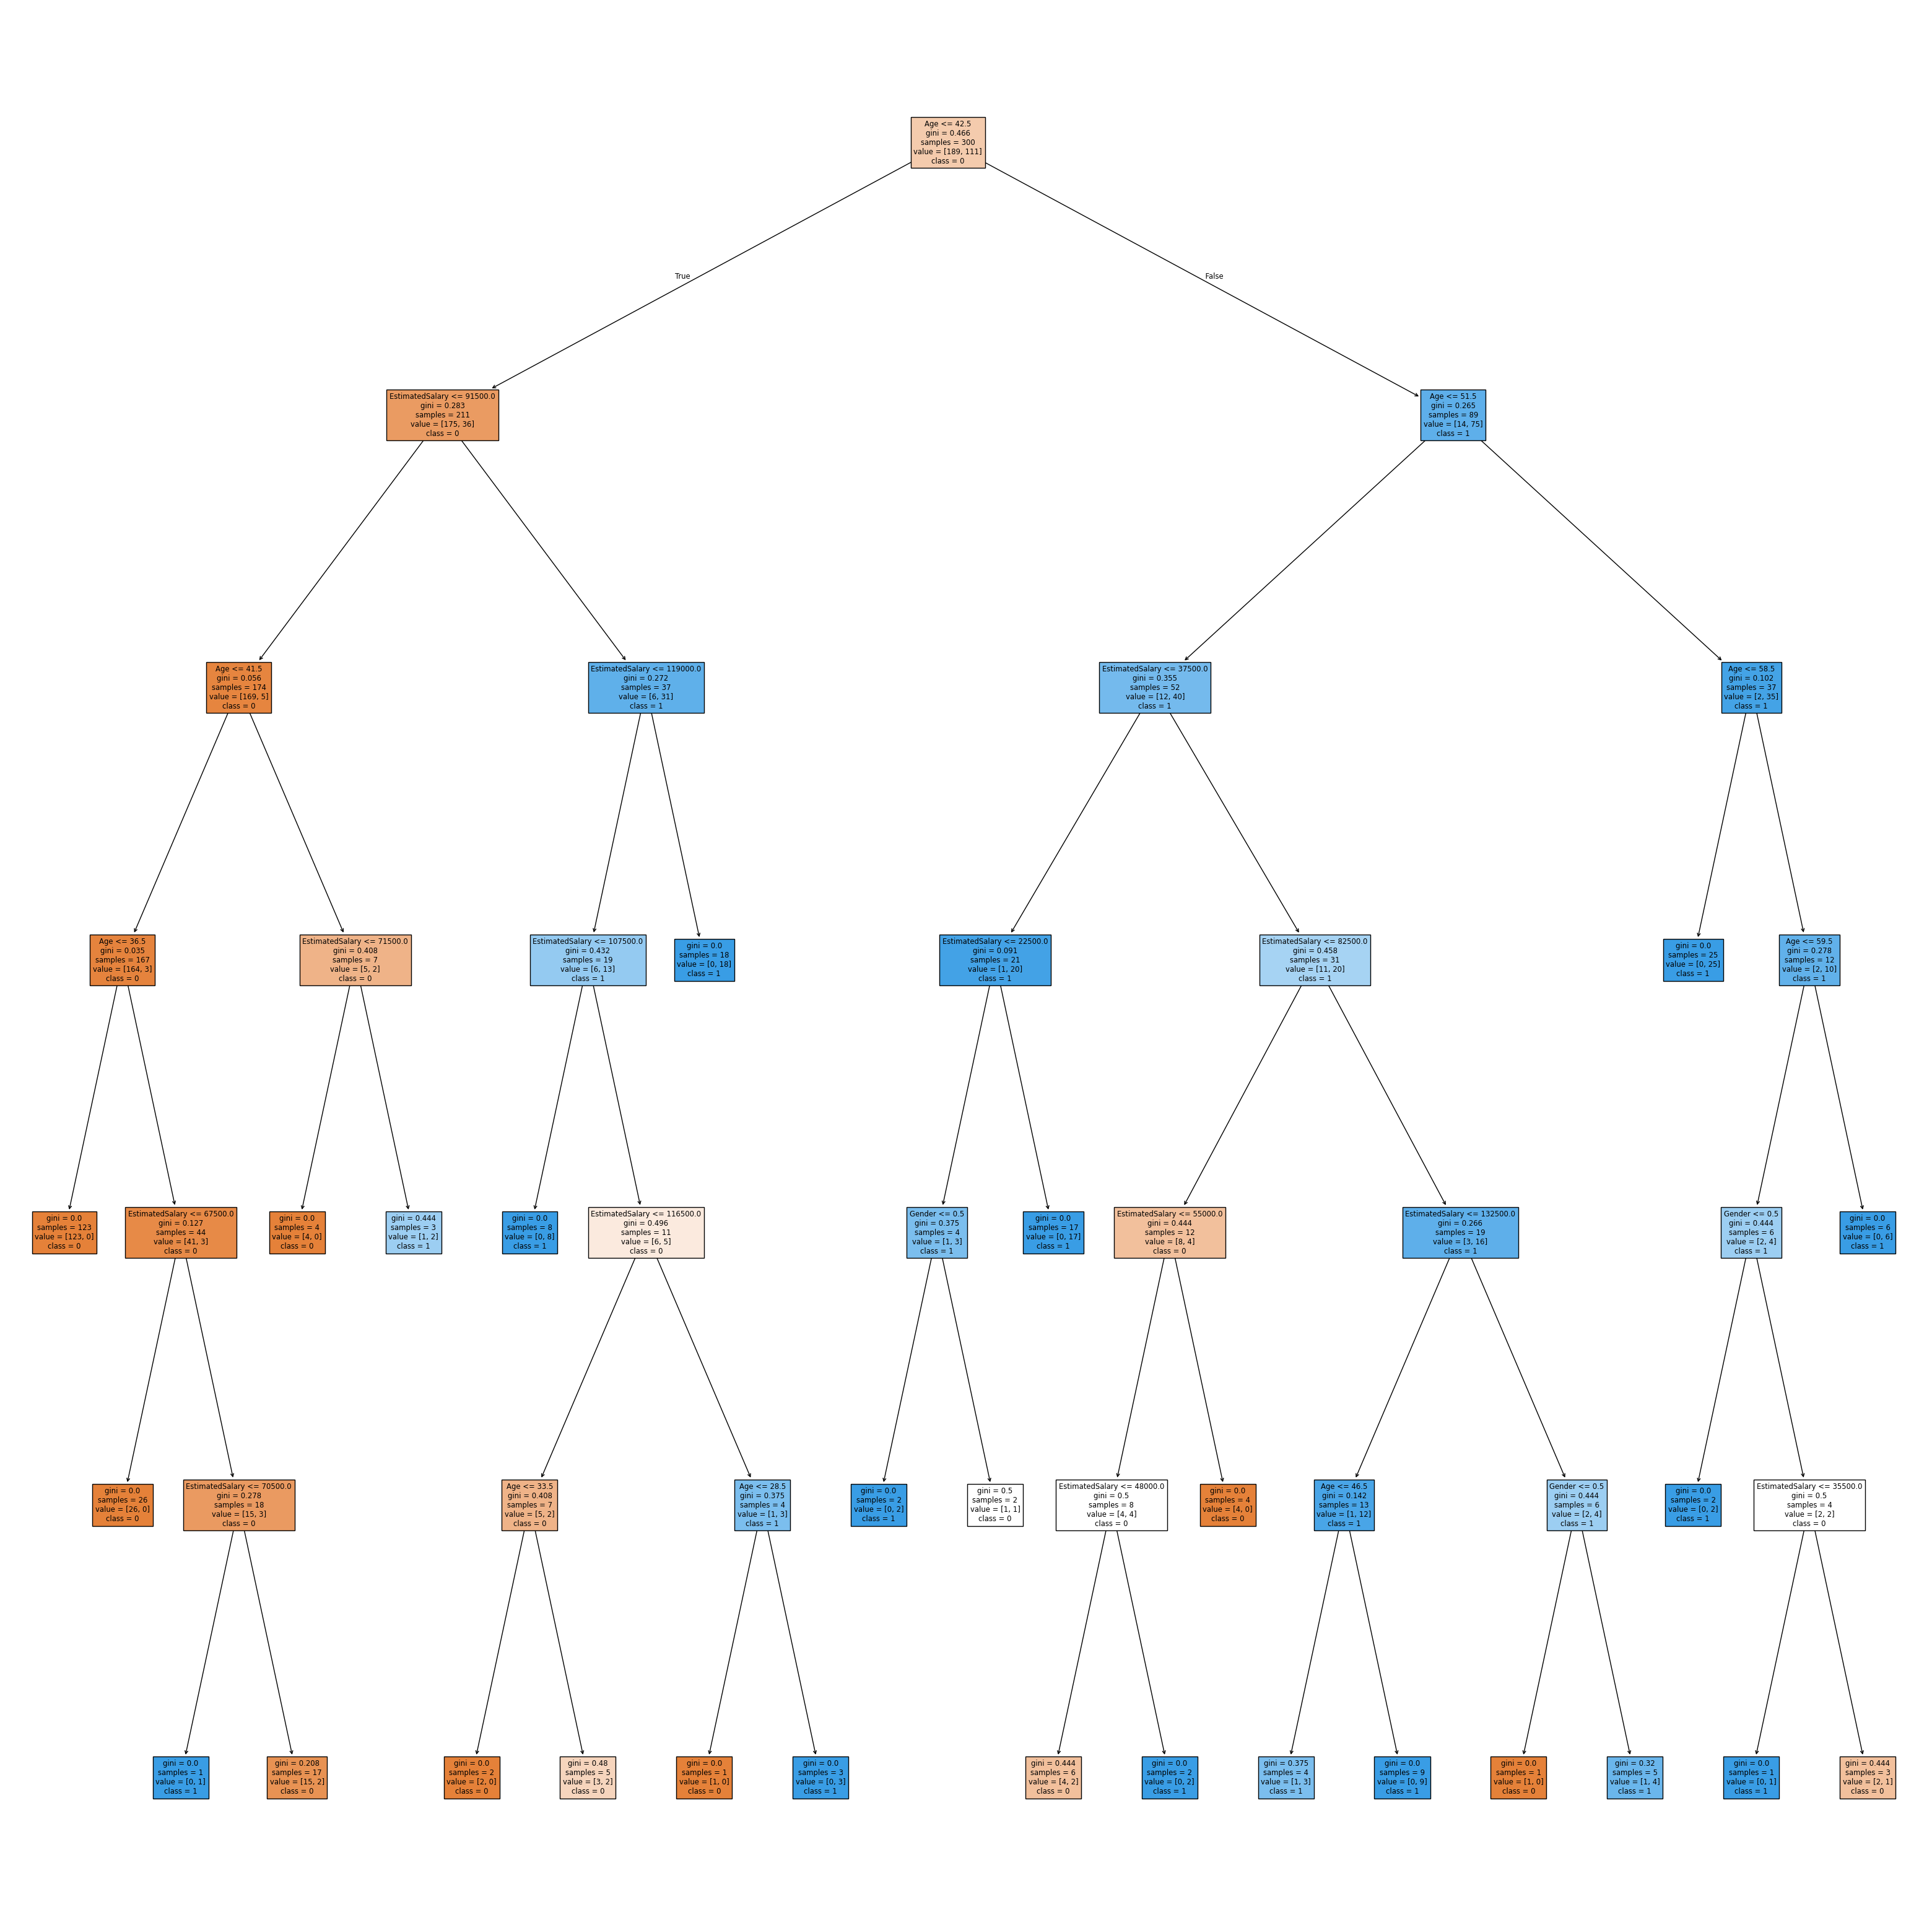

In [34]:
plt.figure(figsize = (40,40))
plot_tree(
    classifier,  # 학습된 모델
    filled=True,  #채워 넣기
    feature_names = X.columns, # 칼럼 이름
    class_names=['0','1']
)
os.makedirs('images_output', exist_ok=True)
plt.savefig('images_output/dt_img.jpg')
plt.show()

# 랜덤포레스트 모델

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred = rf_classifier.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

In [67]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [68]:
confusion_matrix(y_test, y_pred)

array([[63,  5],
       [ 6, 26]])

In [69]:
from sklearn.metrics import classification_report

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.89

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        68
           1       0.84      0.81      0.83        32

    accuracy                           0.89       100
   macro avg       0.88      0.87      0.87       100
weighted avg       0.89      0.89      0.89       100



In [75]:
y_proba = rf_classifier.predict_proba(X_test)

# xgboost 모델 사용

In [48]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [80]:
params = {
    "max_depth": 6,
    "learning_rate": 0.05,
    "n_estimators": 800,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "gamma": 0.1,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "logloss"
}

In [49]:
from xgboost import XGBClassifier

In [90]:
xgb_classifier = XGBClassifier(**params)

In [91]:
xgb_classifier.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [92]:
y_pred = xgb_classifier.predict(X_test)

In [85]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.9

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        68
           1       0.87      0.81      0.84        32

    accuracy                           0.90       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.90      0.90      0.90       100



정확도: 0.87

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.90      0.90        68
           1       0.79      0.81      0.80        32

    accuracy                           0.87       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.87      0.87      0.87       100


In [93]:
y_proba = xgb_classifier.predict_proba(X_test)

In [94]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

In [98]:
xgb_classifier.predict_proba(X_test)

array([[1.11390591e-01, 8.88609409e-01],
       [9.99206185e-01, 7.93791143e-04],
       [7.51995265e-01, 2.48004720e-01],
       [9.65646625e-01, 3.43533568e-02],
       [8.38854969e-01, 1.61145046e-01],
       [2.61275768e-02, 9.73872423e-01],
       [1.73939168e-01, 8.26060832e-01],
       [8.62191916e-01, 1.37808070e-01],
       [8.26106668e-02, 9.17389333e-01],
       [9.97869253e-01, 2.13072728e-03],
       [9.98237610e-01, 1.76241912e-03],
       [4.76474166e-02, 9.52352583e-01],
       [9.93800700e-01, 6.19930308e-03],
       [1.33252919e-01, 8.66747081e-01],
       [8.80172670e-01, 1.19827315e-01],
       [1.00102961e-01, 8.99897039e-01],
       [9.92036998e-01, 7.96298590e-03],
       [9.96663630e-01, 3.33635369e-03],
       [5.01004577e-01, 4.98995423e-01],
       [6.24934018e-01, 3.75065982e-01],
       [9.87602532e-01, 1.23974904e-02],
       [9.98544574e-01, 1.45541423e-03],
       [8.74127150e-02, 9.12587285e-01],
       [5.38312793e-02, 9.46168721e-01],
       [9.955098

In [95]:
y_proba = xgb_classifier.predict_proba(X_test)[:,1]

In [96]:
thresholds = [0.3, 0.5, 0.7, 0.9]
for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    print(f"\n=== Threshold: {threshold} ===")
    print(classification_report(y_test, y_pred))


=== Threshold: 0.3 ===
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        68
           1       0.77      0.84      0.81        32

    accuracy                           0.87       100
   macro avg       0.85      0.86      0.85       100
weighted avg       0.87      0.87      0.87       100


=== Threshold: 0.5 ===
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        68
           1       0.87      0.81      0.84        32

    accuracy                           0.90       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.90      0.90      0.90       100


=== Threshold: 0.7 ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        68
           1       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
we

In [102]:
precision_recall_curve(y_test, y_proba)

(array([0.32      , 0.32323232, 0.32653061, 0.32989691, 0.33333333,
        0.33684211, 0.34042553, 0.34408602, 0.34782609, 0.35164835,
        0.35555556, 0.35955056, 0.36781609, 0.37209302, 0.37647059,
        0.38095238, 0.38554217, 0.3902439 , 0.39506173, 0.4       ,
        0.40506329, 0.41025641, 0.41558442, 0.42105263, 0.42666667,
        0.43243243, 0.43835616, 0.44444444, 0.45070423, 0.45714286,
        0.46376812, 0.47058824, 0.47761194, 0.48484848, 0.49230769,
        0.5       , 0.50793651, 0.51612903, 0.52459016, 0.51666667,
        0.52542373, 0.53448276, 0.55357143, 0.56363636, 0.58490566,
        0.59615385, 0.60784314, 0.62      , 0.63265306, 0.65957447,
        0.67391304, 0.66666667, 0.65909091, 0.6744186 , 0.69047619,
        0.70731707, 0.725     , 0.71794872, 0.71052632, 0.72972973,
        0.75      , 0.77142857, 0.76470588, 0.8125    , 0.83870968,
        0.86666667, 0.89655172, 0.89285714, 0.88888889, 0.88461538,
        0.92      , 0.91666667, 0.91304348, 0.90

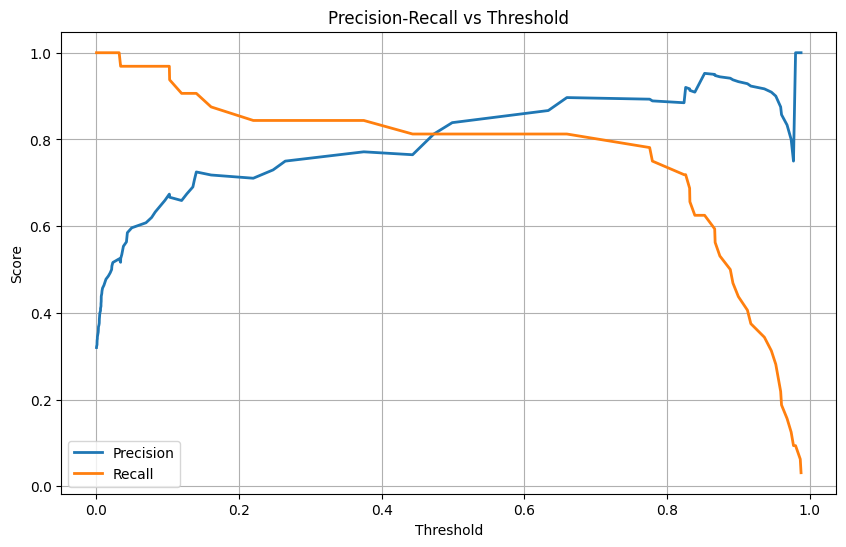

Optimal Threshold (F1 maximized): 0.660
Precision: 0.897
Recall: 0.812
F1-Score: 0.852


In [97]:
# Precision-Recall curve 계산
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid(True)
plt.show()

# F1-Score가 최대인 threshold 찾기
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold (F1 maximized): {optimal_threshold:.3f}")
print(f"Precision: {precision[optimal_idx]:.3f}")
print(f"Recall: {recall[optimal_idx]:.3f}")
print(f"F1-Score: {f1_scores[optimal_idx]:.3f}")

In [103]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.6957720588235294